# 04 – Geospatial Visualization
Scatter plots of transaction locations (`Lng`/`Lat`), colored and sized by property attributes, with map imagery as background.

**Input:** `housing_extended.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

housing_extended = pd.read_csv('../data/processed/housing_extended.csv', encoding='gbk')
housing_extended.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital,pricePerSquare
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996,3167.938931
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224,4343.556428
2,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041,2220.149254
3,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335,4839.506173
4,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652,5200.000000


## Sample the data
Only every 100th row is plotted to keep the notebook and its outputs light.

In [2]:
housing_sample = housing_extended.iloc[:-100:100]
housing_sample.shape

(2850, 20)

## Transaction locations
The axes use equal scaling. Transactions are concentrated around the city center.

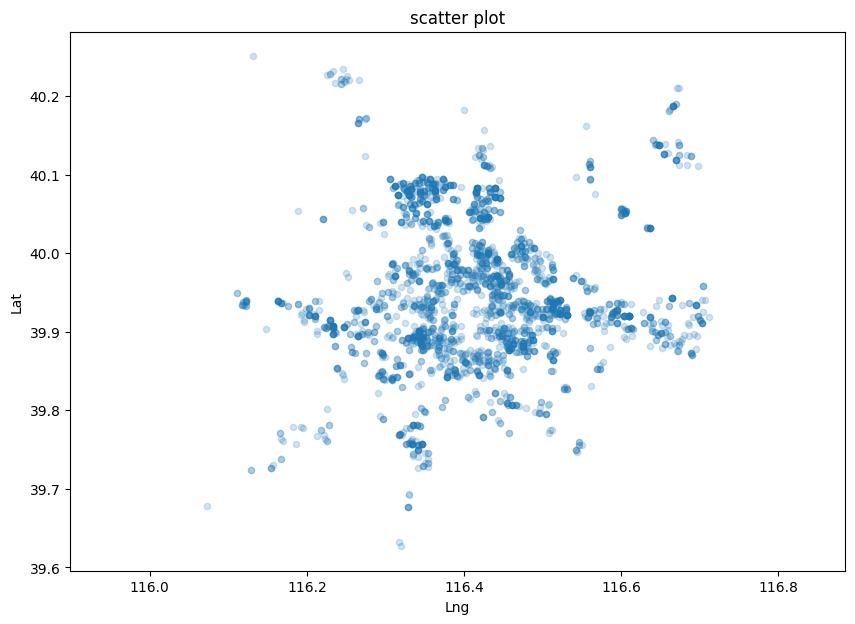

In [3]:
fig1 , ax1 = plt.subplots()
fig1.set_size_inches(10,7)

housing_sample.plot(x='Lng', y='Lat', ax=ax1, kind='scatter', alpha=0.2)
ax1.axis('equal')
ax1.set_title('scatter plot');

## Color by price per m²
The `jet` colormap maps higher prices to warmer colors. Prices are highest near the center and decline with distance.

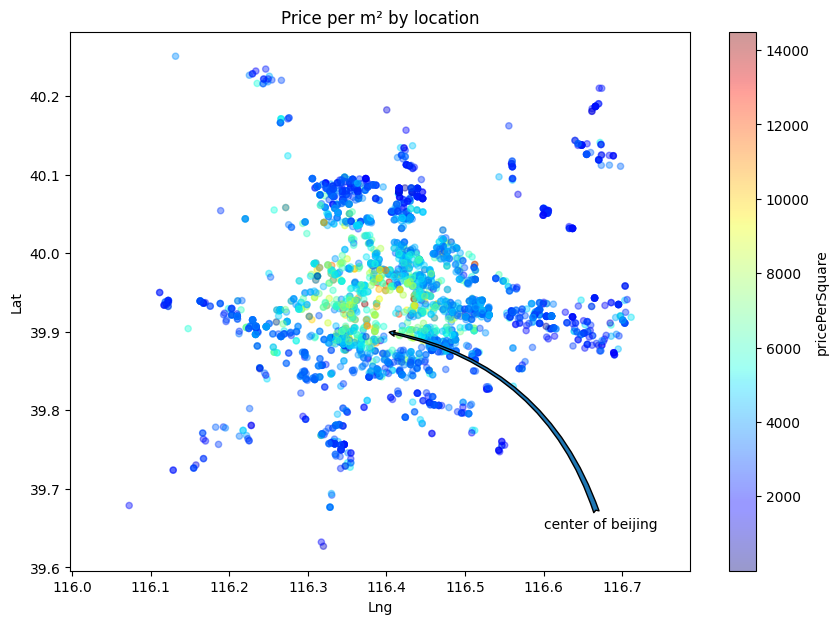

In [4]:
from matplotlib.patches import ConnectionStyle

fig2, ax2 = plt.subplots(figsize=(10, 7))
housing_sample.plot(x='Lng', y='Lat', ax=ax2, kind='scatter', alpha=0.4,
                    c='pricePerSquare', cmap='jet', colorbar=True)
ax2.axis('equal')
ax2.annotate('center of beijing', xy=(116.40, 39.90), xytext=(116.6, 39.65),
             arrowprops=dict(arrowstyle='fancy', connectionstyle=ConnectionStyle('Arc3', rad=0.3)))
ax2.set_title('Price per m² by location')
fig2.savefig('../reports/figures/price_map.png', dpi=130, bbox_inches='tight');

## Size by distance to the center, with map background
`imshow(..., extent=[lon_min, lon_max, lat_min, lat_max])` aligns the background image with the data coordinates.

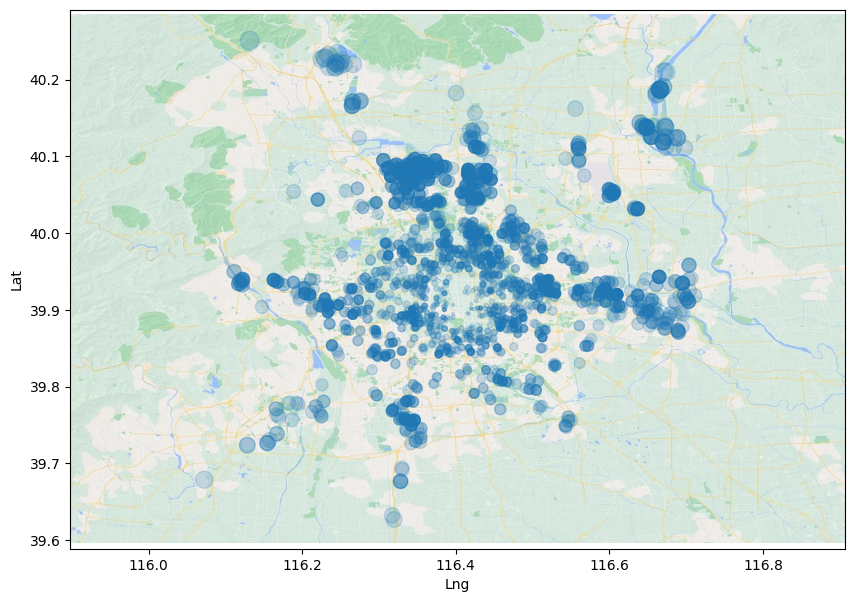

In [5]:
import matplotlib.image as mpimg

fig3, ax3 = plt.subplots(figsize=(10, 7))

housing_sample.plot(x = 'Lng' , y ='Lat' ,ax = ax3, kind = 'scatter', alpha = 0.2,\
    s = housing_sample['distanceToCapital'] * 4)

ax3.axis('equal')

beijing_img = mpimg.imread('../assets/map1.jpg')
ax3.imshow(beijing_img, extent=[115.89777890444654, 116.90711309555346, 39.5957436, 40.2840444]);

## Color by district, size by floor area
Marker size is `square / 20`; color comes from the `nipy_spectral` colormap.

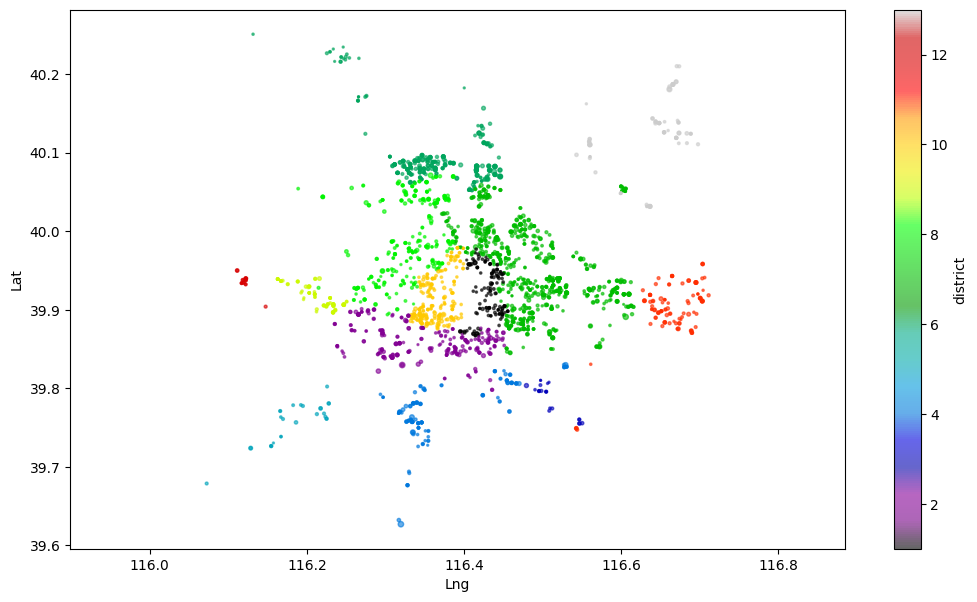

In [6]:
fig4, ax4 = plt.subplots()
fig4.set_size_inches(12.5, 7)

housing_sample.plot(
    x='Lng',
    y='Lat',
    ax=ax4,
    kind='scatter',
    c='district',
    s=housing_sample['square'] / 20,
    cmap='nipy_spectral',
    alpha=0.6
)

ax4.axis('equal');

## Properties 10–30 km from the center
Same encoding as above, restricted to a distance band (exclusive) and drawn over a second map image.

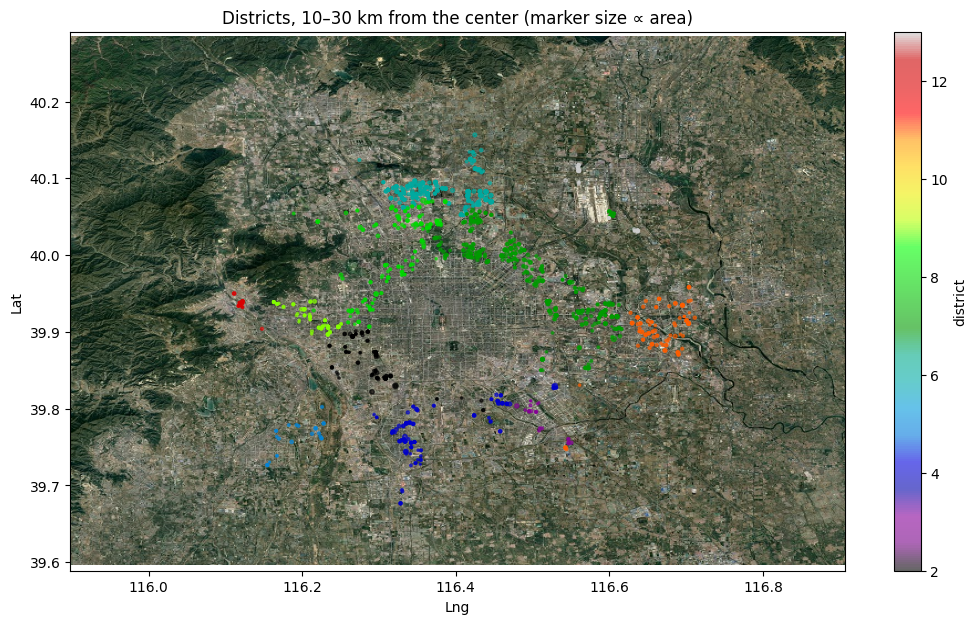

In [7]:
import matplotlib.image as mpimg

housing_10_30 = housing_sample[
    (housing_sample['distanceToCapital'] > 10) &
    (housing_sample['distanceToCapital'] < 30)
]

fig5, ax5 = plt.subplots()
fig5.set_size_inches(12.5, 7)

housing_10_30.plot(
    x='Lng',
    y='Lat',
    ax=ax5,
    kind='scatter',
    c='district',
    s=housing_10_30['square'] / 20,
    cmap='nipy_spectral',
    alpha=0.6
)

beijing_img = mpimg.imread('../assets/map2.jpg')

ax5.imshow(
    beijing_img,
    extent=[115.89777890444654, 116.90711309555346, 39.5957436, 40.2840444]
)

ax5.axis('equal')
ax5.set_title('Districts, 10–30 km from the center (marker size ∝ area)')
fig5.savefig('../reports/figures/districts_map.png', dpi=130, bbox_inches='tight');